In [13]:
import os
import sys
import torch
import matplotlib.pyplot as plt
ROOT_DIR = os.path.dirname(os.path.dirname(os.getcwd()))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)
from electron_optics import model

In [14]:
PREDICTORS=["predictor1"]
DROPOUT=[0.0, 0.1, 0.2, 0.3, 0.4]

In [15]:
data_collection={}
for predictor in PREDICTORS:
    for dropout in DROPOUT:
        checkpoint_path=f"{predictor}_{dropout}.pt"
        data=torch.load(checkpoint_path)
        data_collection[f'{predictor}_{dropout}']=data

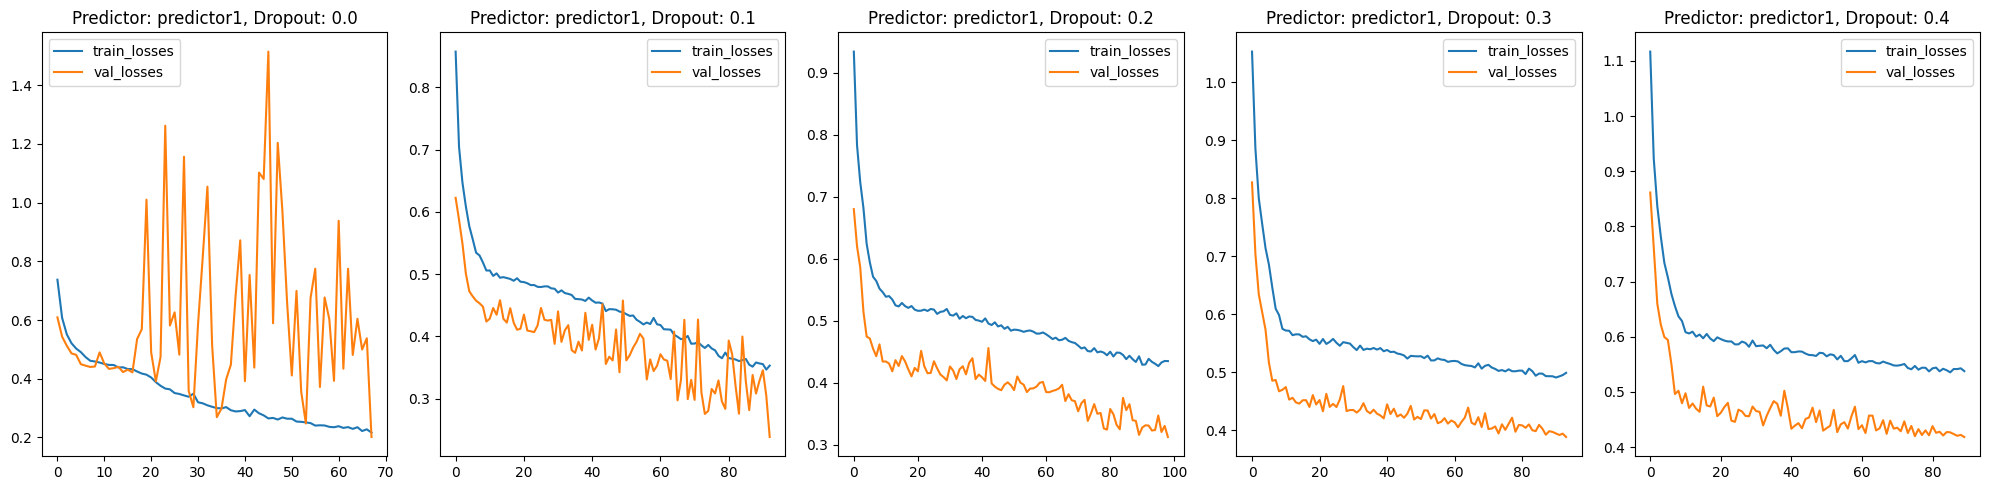

In [16]:
fig, ax = plt.subplots(len(PREDICTORS), len(DROPOUT), figsize=(20, 5))

# Handle the case where we have only one row of subplots
if len(PREDICTORS) == 1:
    ax = ax.reshape(1, -1)  # Ensure ax is always 2D

for i, predictor in enumerate(PREDICTORS):
    for j, dropout in enumerate(DROPOUT):
        ax[i,j].plot(data_collection[f'{predictor}_{dropout}']['train_losses'], label='train_losses')
        ax[i,j].plot(data_collection[f'{predictor}_{dropout}']['val_losses'], label='val_losses')
        ax[i,j].set_title(f'Predictor: {predictor}, Dropout: {dropout}')
        ax[i,j].legend()
plt.tight_layout()
plt.show()